# Loan Default Risk Prediction — Project Report

Structured notebook covering: Executive Summary, Problem Definition, Dataset Description, Data Preprocessing, EDA, Model Building, Evaluation, Insights, Business Recommendations.

**Executive Summary**
- Goal: Predict loan default to support lending decisions and reduce portfolio losses.
- Approach: Clean data, feature-engineer, run EDA, train two models (Logistic Regression, Random Forest), compare and provide business recommendations.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from imblearn.over_sampling import SMOTE
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
# Load data
df = pd.read_csv('Loan_default.csv')
print('Rows, cols:', df.shape)
df.head()

Rows, cols: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


**Problem Definition**
Classify whether a loan will default (`Default` column) — a binary classification problem.

**Dataset Description**
Columns include borrower demographics, loan attributes, credit metrics and the `Default` label. Use `df.info()` and `df.describe()` to inspect types and distributions.

In [4]:
# Quick dataset overview
display(df.info())
display(df.describe(include='all'))
print('Target distribution:', df['Default'].value_counts(normalize=True).mul(100).round(2))

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

None

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347,255347,255347,255347,255347,255347,255347.000000
unique,255347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,2,5,2,NaN
top,I38PQUQS96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64366,64161,85302,127677,127742,51298,127701,NaN
mean,NaN,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116128
std,NaN,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320379
min,NaN,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


Target distribution: Default
0    88.39
1    11.61
Name: proportion, dtype: float64


## Data Preprocessing
Steps: missing values, feature engineering, encoding, scaling.

In [5]:
# Drop identifier
if 'LoanID' in df.columns:
    df = df.drop('LoanID', axis=1)
# Feature engineering (derived features)
df['LoanToIncomeRatio'] = df['LoanAmount'] / df['Income'].replace(0, np.nan)
df['MonthlyPaymentEst'] = (df['LoanAmount'] / df['LoanTerm']) * (1 + df['InterestRate'] / 100)
df['CreditRiskFlag'] = (df['CreditScore'] < 600).astype(int)
df['HighDTIFlag'] = (df['DTIRatio'] > 0.5).astype(int)
df['UnemployedFlag'] = (df.get('EmploymentType') == 'Unemployed').astype(int)
df['ShortEmploymentFlag'] = (df['MonthsEmployed'] < 12).astype(int)
# Fill edge-case NaNs
df['LoanToIncomeRatio'] = df['LoanToIncomeRatio'].fillna(df['LoanToIncomeRatio'].median())

In [6]:
# Missing values: numeric -> median, categorical -> mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])
# Verify
print(df.isnull().sum().sum(), 'total missing values remain')

0 total missing values remain


In [7]:
# Encoding categorical features using LabelEncoder (simple and reproducible)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
joblib.dump(label_encoders, MODELS_DIR / 'label_encoders.pkl')
print('Saved label_encoders.pkl')

Saved label_encoders.pkl


In [8]:
# Scaling numeric features
numerical_cols = [c for c in num_cols if c != 'Default']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print('Saved scaler.pkl')

Saved scaler.pkl


## Exploratory Data Analysis (EDA)
Univariate + Bivariate analyses and correlation.

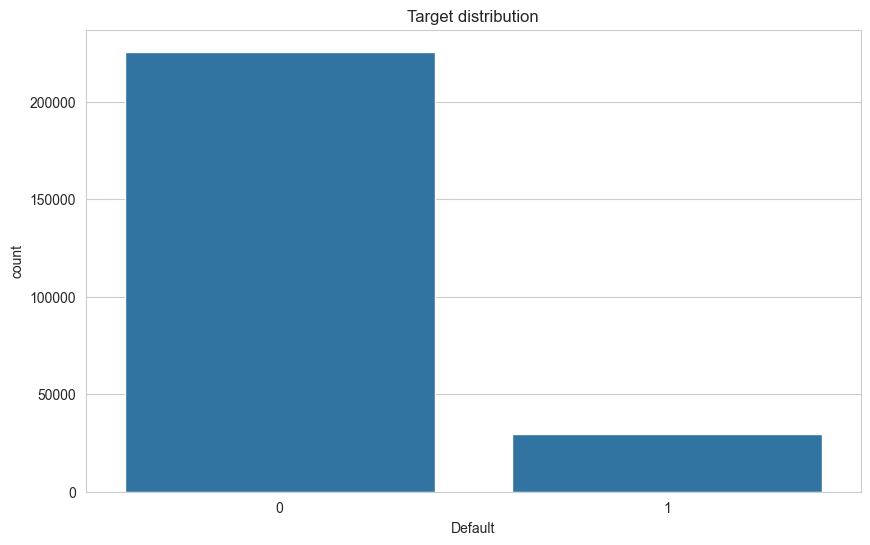

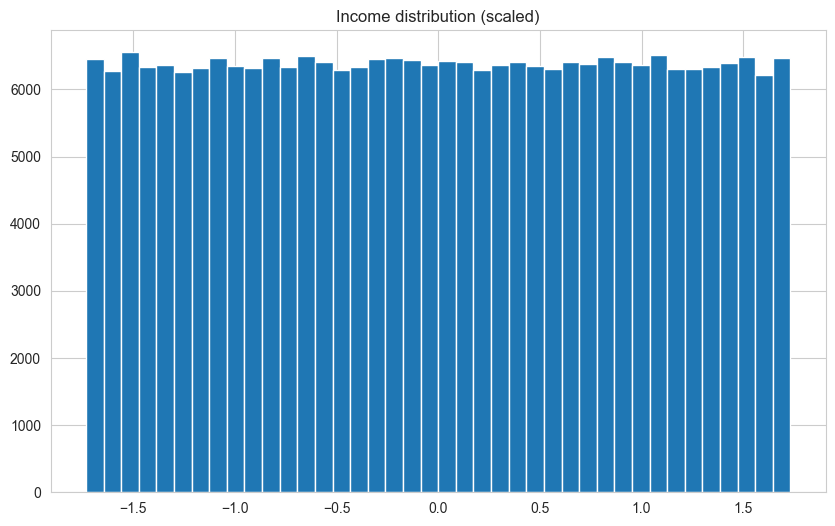

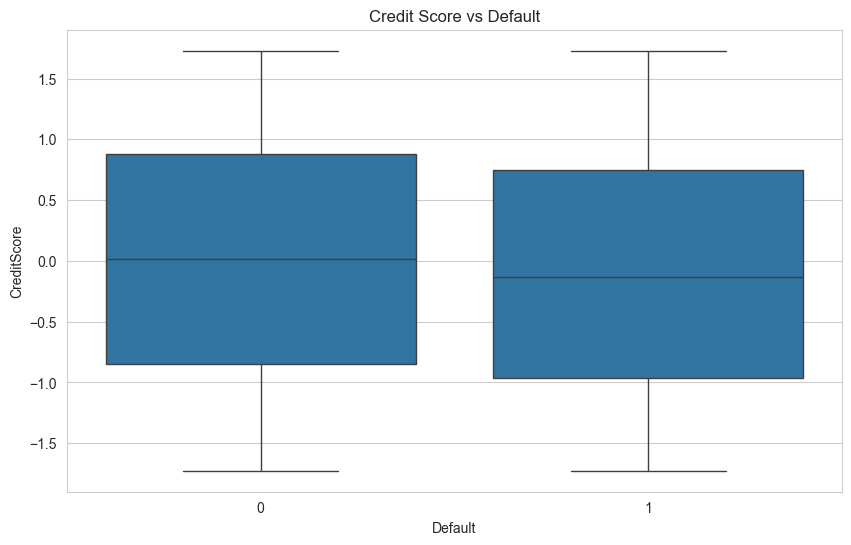

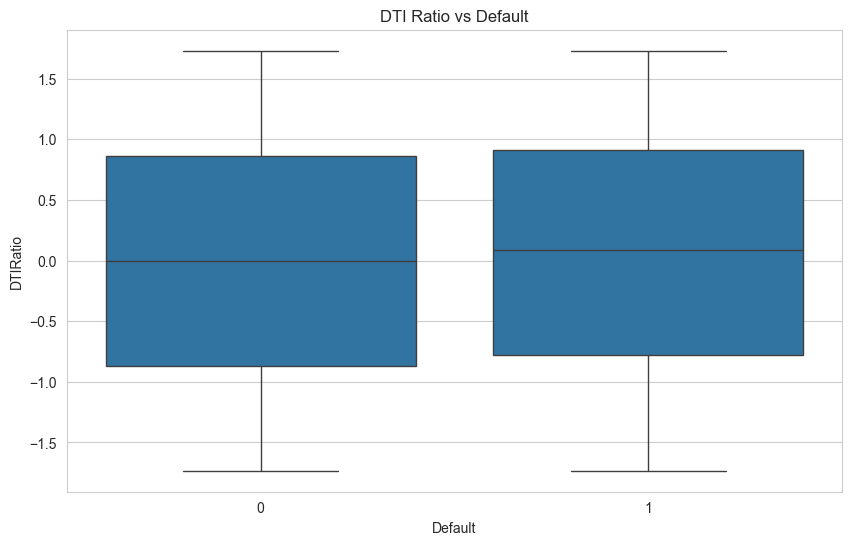

In [9]:
# Univariate: target balance
sns.countplot(x='Default', data=df)
plt.title('Target distribution')
plt.show()
# Univariate: income distribution (scaled)
plt.hist(df['Income'], bins=40)
plt.title('Income distribution (scaled)')
plt.show()
# Bivariate: CreditScore vs Default
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title('Credit Score vs Default')
plt.show()
# DTI vs Default
sns.boxplot(x='Default', y='DTIRatio', data=df)
plt.title('DTI Ratio vs Default')
plt.show()

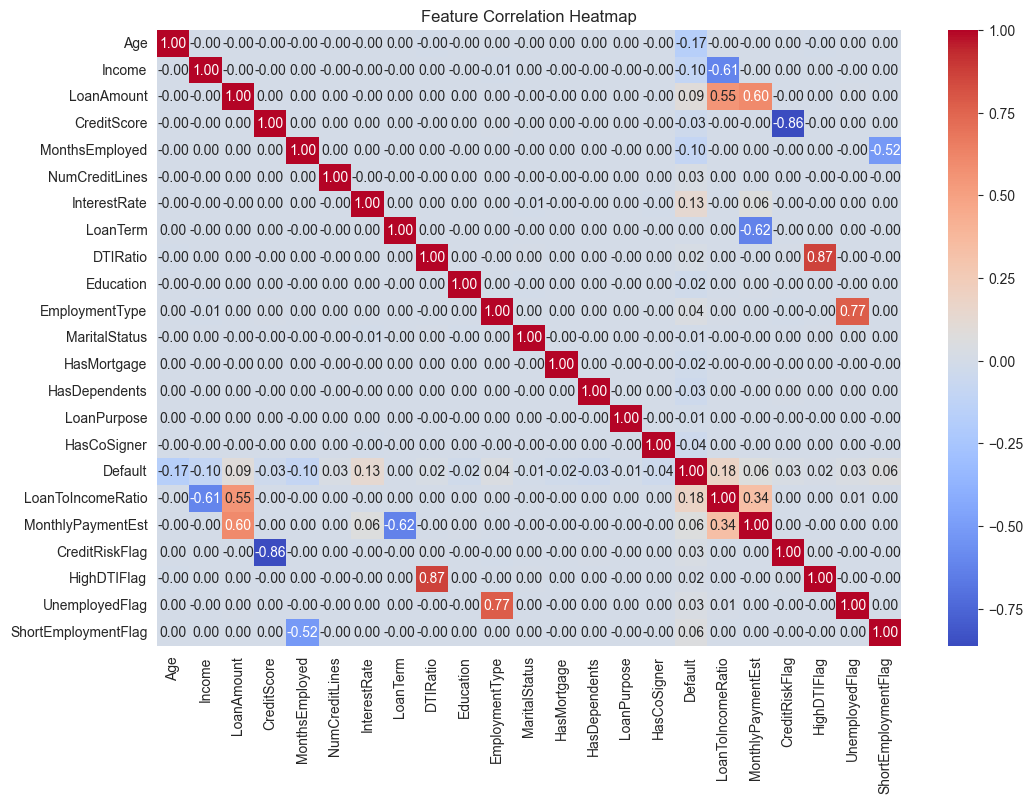

In [10]:
# Correlation analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Model Building
Train at least two models and compare performance on validation set.

In [11]:
# Features and target
X = df.drop('Default', axis=1)
y = df['Default']
# Train/validation/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('After SMOTE:', y_train_smote.value_counts())
# Train models
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
lr.fit(X_train_smote, y_train_smote)
rf.fit(X_train_smote, y_train_smote)
joblib.dump(lr, MODELS_DIR / 'lr_model.pkl')
joblib.dump(rf, MODELS_DIR / 'rf_model.pkl')
print('Saved lr_model.pkl and rf_model.pkl')

After SMOTE: Default
0    157985
1    157985
Name: count, dtype: int64
Saved lr_model.pkl and rf_model.pkl


In [13]:
# Evaluate on validation set
models = {'LogisticRegression': lr, 'RandomForest': rf}
results = []
for name, m in models.items():
    y_pred = m.predict(X_val)
    y_prob = m.predict_proba(X_val)[:,1] if hasattr(m, 'predict_proba') else m.decision_function(X_val)
    res = {
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred),
        'ROC_AUC': roc_auc_score(y_val, y_prob)
    }
    results.append(res)
    print('Model:', name)
    print(classification_report(y_val, y_pred, zero_division=0))
    print('Confusion matrix:', confusion_matrix(y_val, y_pred))

Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.93      0.73      0.82     33854
           1       0.23      0.60      0.33      4448

    accuracy                           0.72     38302
   macro avg       0.58      0.67      0.58     38302
weighted avg       0.85      0.72      0.76     38302

Confusion matrix: [[24849  9005]
 [ 1783  2665]]
Model: RandomForest
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     33854
           1       0.24      0.54      0.33      4448

    accuracy                           0.75     38302
   macro avg       0.58      0.66      0.59     38302
weighted avg       0.85      0.75      0.78     38302

Confusion matrix: [[26177  7677]
 [ 2055  2393]]


,Model,Accuracy,Precision,Recall,ROC_AUC
0,LogisticRegression,0.718344,0.228363,0.599146,0.731504
1,RandomForest,0.745914,0.237637,0.537995,0.724220


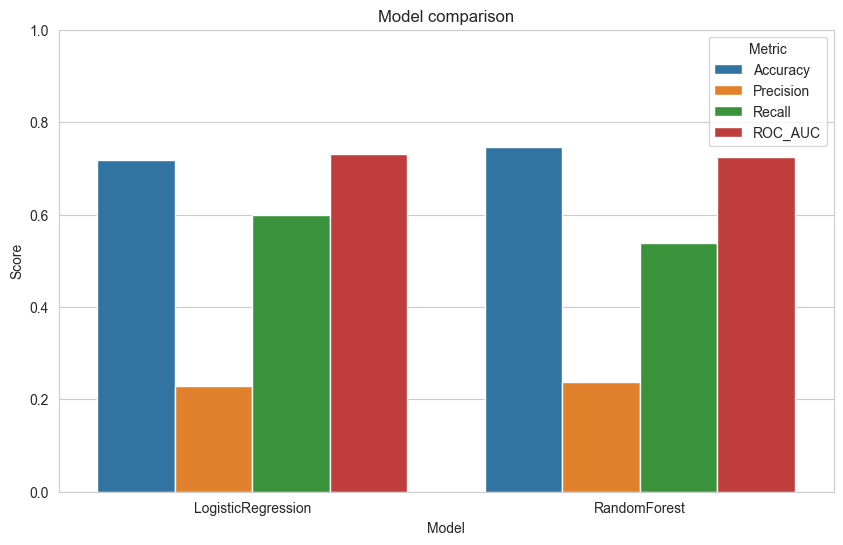

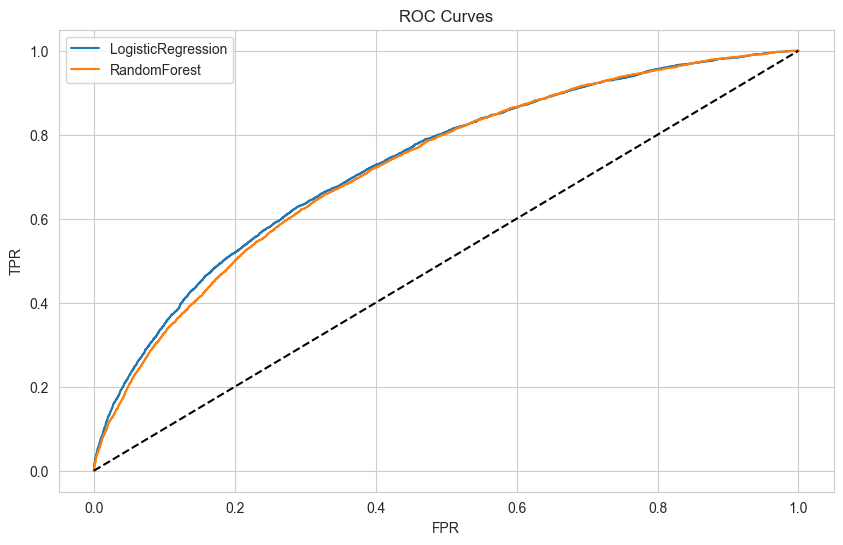

In [14]:
# Compare results
results_df = pd.DataFrame(results).sort_values(by='ROC_AUC', ascending=False)
display(results_df)
# Simple bar plot
metrics_melt = results_df.melt(id_vars='Model', value_vars=['Accuracy','Precision','Recall','ROC_AUC'], var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melt, x='Model', y='Score', hue='Metric')
plt.ylim(0,1)
plt.title('Model comparison')
plt.show()
# ROC curves
plt.figure()
for name, m in models.items():
    y_prob = m.predict_proba(X_val)[:,1] if hasattr(m, 'predict_proba') else m.decision_function(X_val)
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves')
plt.legend()
plt.show()

## Insights (interpretation)
- Summarize which features drive defaults (use feature importance from `RandomForest`).
- Relate model behavior to business meaning: e.g., high `DTIRatio` and low `CreditScore` increase default probability; high `LoanToIncomeRatio` signals repayment stress.

,Feature,Importance
0,Age,0.210286
6,InterestRate,0.118326
13,HasDependents,0.096688
15,HasCoSigner,0.093435
5,NumCreditLines,0.088617
16,LoanToIncomeRatio,0.084651
12,HasMortgage,0.069166
4,MonthsEmployed,0.055496
7,LoanTerm,0.044637
1,Income,0.031459


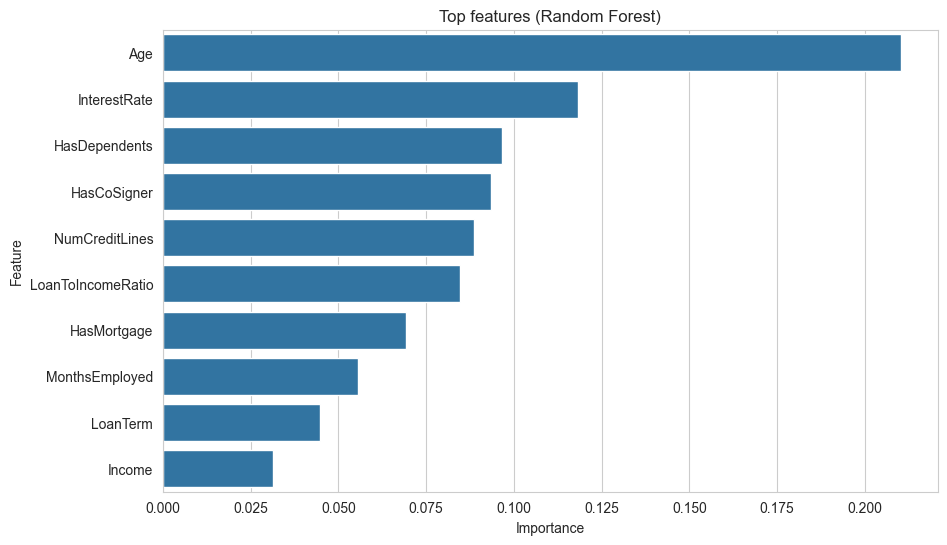

In [15]:
# Feature importance from Random Forest
fi = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
display(fi.head(10))
sns.barplot(data=fi.head(10), x='Importance', y='Feature')
plt.title('Top features (Random Forest)')
plt.show()

## Business Recommendations
- Use the probability score as a decision aid rather than a hard rule.
- Auto-approve low-risk segment, manual review for medium-risk, decline or restructure high-risk.
- Monitor top risk drivers (Credit Score, DTI, LoanToIncomeRatio) and retrain quarterly.
- Add explainability (SHAP) for regulatory transparency.

## Artifacts & Next Steps
- Saved models: `models/lr_model.pkl`, `models/rf_model.pkl`
- Saved preprocessing: `models/scaler.pkl`, `models/label_encoders.pkl`
- Next: run the notebook end-to-end, fine-tune hyperparameters, add SHAP explanations, and produce a one-page executive summary slide.